<a href="https://colab.research.google.com/github/WendyValdes/Recognition-of-Friends-characters./blob/main/recon_facil_friends.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installation of dependencies

In [58]:
!pip install kagglehub opencv-python tensorflow scikit-learn matplotlib

Dataset download

In [59]:
import kagglehub

path = kagglehub.dataset_download(
    "amiralikalbasi/images-of-friends-character-for-face-recognition"
)

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'images-of-friends-character-for-face-recognition' dataset.
Path to dataset files: /kaggle/input/images-of-friends-character-for-face-recognition


Face preprocessing and detection

In [71]:
import cv2
import os
import numpy as np

IMG_SIZE = 128

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def carregar_dados(dataset_path):
    X, y = [], []
    unique_classes = []
    label_map = {}
    current_label = 0

    print(f"Checking dataset path: {dataset_path}")
    if not os.path.exists(dataset_path):
        print(f"Error: Dataset path does not exist: {dataset_path}")
        return np.array(X), np.array(y), []

    # Assuming the structure is dataset_path/Friends/Train/CharacterName/image.jpg
    # and dataset_path/Friends/Test/CharacterName/image.jpg
    base_friends_path = os.path.join(dataset_path, 'Friends')

    if not os.path.isdir(base_friends_path):
        print(f"Error: 'Friends' directory not found at {base_friends_path}")
        return np.array(X), np.array(y), []

    # Iterate through 'Train' and 'Test' subfolders
    for subset_name in ['Train', 'Test']:
        subset_path = os.path.join(base_friends_path, subset_name)
        if not os.path.isdir(subset_path):
            print(f"Warning: '{subset_name}' directory not found at {subset_path}. Skipping.")
            continue
        print(f"Processing subset folder: {subset_path}")

        # Iterate through character folders (e.g., 'Joey', 'Rachel')
        character_folders = sorted(os.listdir(subset_path))
        for character_name in character_folders:
            character_path = os.path.join(subset_path, character_name)
            if not os.path.isdir(character_path):
                print(f"Skipping non-directory item in subset: {character_path}")
                continue

            # Assign a unique label to each character
            if character_name not in label_map:
                label_map[character_name] = current_label
                unique_classes.append(character_name)
                current_label += 1
            label = label_map[character_name]

            print(f"Processing character folder: {character_path} (Class: {character_name}, Label: {label})")

            # Iterate through image files in the character folder
            images_in_folder = os.listdir(character_path)
            if not images_in_folder:
                print(f"No files found in folder: {character_path}")
                continue

            for img_name in images_in_folder:
                img_path = os.path.join(character_path, img_name)
                if not os.path.isfile(img_path):
                    print(f"Skipping non-file item: {img_path}")
                    continue

                img = cv2.imread(img_path)

                if img is None: # Added img.size check to make sure it's not an empty image
                    print(f"Failed to load image or image is empty: {img_path}")
                    continue

                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                faces = face_cascade.detectMultiScale(gray, 1.3, 5)

                if len(faces) == 0:
                    # print(f"No faces detected in image: {img_path}") # Uncomment for verbose output on no-face images
                    pass
                else:
                    # print(f"Detected {len(faces)} face(s) in image: {img_path}")
                    pass

                for (x, y_, w, h) in faces:
                    face = gray[y_:y_+h, x:x+w]
                    face = cv2.resize(face, (IMG_SIZE, IMG_SIZE))

                    # Convert 1-channel grayscale face to 3-channel by stacking for training
                    face_3_channel = np.stack([face, face, face], axis=-1)

                    X.append(face_3_channel)
                    y.append(label)

    print(f"Finished processing. Total faces detected and added to dataset: {len(X)}")
    print(f"Detected classes: {unique_classes}")
    # X will now be a list of (IMG_SIZE, IMG_SIZE, 3) arrays, np.array(X) will produce (num_samples, IMG_SIZE, IMG_SIZE, 3)
    return np.array(X), np.array(y), unique_classes


Data preparation

In [72]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import numpy as np # Import numpy for np.size

X, y, class_names = carregar_dados(path)

# Check if y is empty before proceeding
if np.size(y) == 0:
    raise ValueError("Erro: Nenhum rosto foi detectado no dataset. Verifique o caminho do dataset e a função carregar_dados para garantir que as imagens são carregadas corretamente e os rostos são detectados.")

X = X / 255.0
# X is already (num_samples, IMG_SIZE, IMG_SIZE, 3) from carregar_dados, no reshape needed for channels here
# The current reshape was for (..., 1) previously, now we ensure it's (..., 3)
# If X is already (N, H, W, C), this reshape does nothing useful or may error if target shape is different.
# Let's remove it and assume carregar_dados correctly returns (N, IMG_SIZE, IMG_SIZE, 3).
# If it still expects 4D, we might need X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 3) later, but it's redundant if previous step is correct.

y = to_categorical(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Checking dataset path: /kaggle/input/images-of-friends-character-for-face-recognition
Processing subset folder: /kaggle/input/images-of-friends-character-for-face-recognition/Friends/Train
Processing character folder: /kaggle/input/images-of-friends-character-for-face-recognition/Friends/Train/Chandler (Class: Chandler, Label: 0)
Processing character folder: /kaggle/input/images-of-friends-character-for-face-recognition/Friends/Train/Joey (Class: Joey, Label: 1)
Processing character folder: /kaggle/input/images-of-friends-character-for-face-recognition/Friends/Train/Monica (Class: Monica, Label: 2)
Processing character folder: /kaggle/input/images-of-friends-character-for-face-recognition/Friends/Train/Phoebe (Class: Phoebe, Label: 3)
Processing character folder: /kaggle/input/images-of-friends-character-for-face-recognition/Friends/Train/Rachel (Class: Rachel, Label: 4)
Processing character folder: /kaggle/input/images-of-friends-character-for-face-recognition/Friends/Train/Ross (Clas

Facial recognition model (simple CNN)

In [73]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
     #Updated input_shape to (IMG_SIZE, IMG_SIZE, 3) to match 3-channel input
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,094 (28.20 MB)

 Trainable params: 7,393,094 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

Training

In [80]:
class_weights = {
    0: 2.5,  # Chandler
    1: 2.0,  # Joey
    2: 1.0,  # Monica
    3: 1.0,  # Phoebe
    4: 2.0,  # Rachel
    5: 1.5   # Ross
}

model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=32
)


Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 972ms/step - accuracy: 0.8928 - loss: 0.3873 - val_accuracy: 0.6552 - val_loss: 0.9241
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 887ms/step - accuracy: 0.8573 - loss: 0.4118 - val_accuracy: 0.6207 - val_loss: 0.9274
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 735ms/step - accuracy: 0.8999 - loss: 0.3214 - val_accuracy: 0.6552 - val_loss: 0.9750
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 894ms/step - accuracy: 0.9361 - loss: 0.2447 - val_accuracy: 0.6552 - val_loss: 0.9670
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 688ms/step - accuracy: 0.9285 - loss: 0.2314 - val_accuracy: 0.6552 - val_loss: 0.9498
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 680ms/step - accuracy: 0.9099 - loss: 0.2483 - val_accuracy: 0.6379 - val_loss: 1.0307
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 859ms/step - accuracy: 0.9514 - loss: 0.1750 - val_accuracy: 0.7069 - val_loss: 1.0736
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 733ms/step - accuracy: 0.9410 - loss: 0.1695 - val_accuracy: 0.6207 - val_loss

In [81]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true, y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    Chandler       0.42      0.56      0.48         9
        Joey       0.67      0.40      0.50        10
      Monica       0.67      1.00      0.80         8
      Phoebe       0.90      0.82      0.86        11
      Rachel       0.57      0.57      0.57         7
        Ross       0.64      0.54      0.58        13

    accuracy                           0.64        58
   macro avg       0.64      0.65      0.63        58
weighted avg       0.65      0.64      0.63        58



Confusion matrix

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step


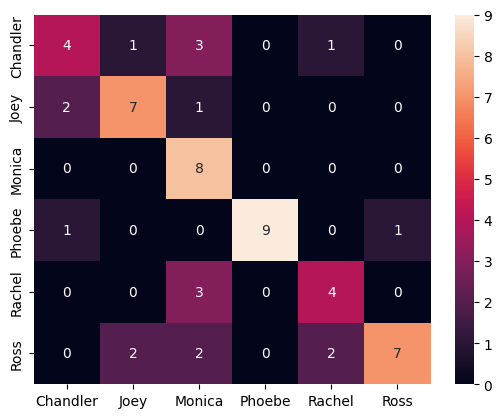

[[4 1 3 0 1 0]
 [2 7 1 0 0 0]
 [0 0 8 0 0 0]
 [1 0 0 9 0 1]
 [0 0 3 0 4 0]
 [0 2 2 0 2 7]]


In [82]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)
plt.show()
print(cm)

Facial recognition in an image

In [83]:
import matplotlib.pyplot as plt

def reconhecer_imagem(img_path):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Could not load image in: {img_path}")
        return

    img_display = img.copy() # Use a copy for drawing rectangles and text

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    if len(faces) == 0:
        print(f"No faces detected in the image.: {img_path}")
        plt.imshow(cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()
        return

    for (x, y, w, h) in faces:
        face_gray = gray[y:y+h, x:x+w]
        margin = int(0.15 * w)
        face = img[y+margin:y+h-margin, x+margin:x+w-margin]
        face_resized = cv2.resize(face_gray, (IMG_SIZE, IMG_SIZE))

        # Convert the grayscale face to a 3-channel image by stacking for prediction
        face_3_channel = np.stack([face_resized, face_resized, face_resized], axis=-1)

        face_normalized = face_3_channel / 255.0
        # Reshape to (1, IMG_SIZE, IMG_SIZE, 3) for model input
        face_input_tensor = face_normalized.reshape(1, IMG_SIZE, IMG_SIZE, 3)

        pred = model.predict(face_input_tensor)
        classe = class_names[np.argmax(pred)]

        cv2.rectangle(img_display, (x,y), (x+w,y+h), (0,255,0), 2)
        cv2.putText(
            img_display, classe, (x, y-10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,0), 2
        )

    plt.imshow(cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


Test

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


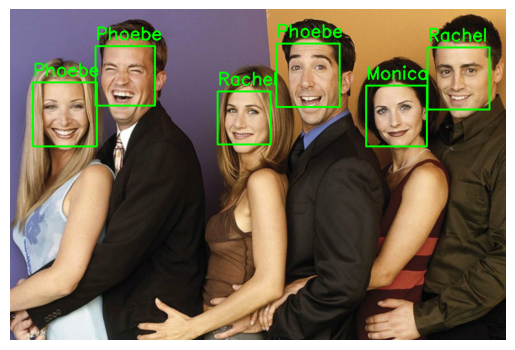

In [84]:
reconhecer_imagem("/Imagemteste/friends-768x512.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


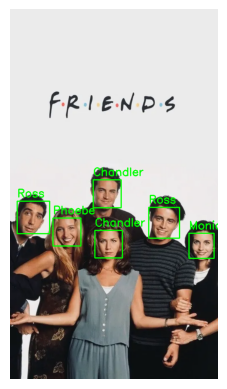

In [79]:
reconhecer_imagem("/Imagemteste/promotional-poster-of-friends-phone-9kxt2dkowcxb5iki.webp")

Although the recognition was not 100% accurate, the results show that several characters were efficiently recognized in the test images. There is still room to improve both the dataset and the model to achieve higher accuracy. However, as a first experiment, the proposed tools and techniques of the project were successfully applied and practiced.